In [26]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter

PLOT_DIR = Path("_plots")
PLOT_DIR.mkdir(parents=True, exist_ok=True)

In [27]:
# Set MANUAL_MAP_CSV env var to override, else first existing file in list wins.
import os

_csv_override = os.environ.get("MANUAL_MAP_CSV")
if _csv_override:
    _csv = Path(_csv_override)
    if not _csv.is_file():
        raise FileNotFoundError(_csv_override)
else:
    for _name in (
        "manual_map_20260522_024408.csv",
        "map_hall_20260522_015838.csv",
        "map_hall_20260522_013851.csv",
        "manual_map_20260522_002236.csv",
        "map_hall_20260514_224724.csv",
        "map_hall_20260514_224801.csv",
        "map_hall_20260514_211326.csv",
        "hallway_full_20260514_192106.csv",
        "hallway_full_20260514_060054.csv",
        "hallway_straight_20260514_054641.csv",
        "hallway_225725.csv",
    ):
        _csv = Path(_name)
        if _csv.is_file():
            break
    else:
        raise FileNotFoundError("No CSV found beside this notebook.")
_plot_stem = _csv.stem
raw_full = pd.read_csv(_csv)
df = raw_full  # alias for older cells below

def _moving_mask(d: pd.DataFrame, min_step_m: float = 0.005) -> np.ndarray:
    x, y = d["x"].to_numpy(), d["y"].to_numpy()
    step = np.hypot(np.diff(x), np.diff(y))
    return np.concatenate([[True], step > min_step_m])

# Trim variants (map_hall: drop row 0 = SLAM startup snap for TUM pipeline)
trim_drop1 = raw_full.iloc[1:].reset_index(drop=True) if _plot_stem.startswith("map_hall") else raw_full.copy()
trim_moving = raw_full.loc[_moving_mask(raw_full)].reset_index(drop=True)

from trim_one_lap import trim_dataframe_one_lap

trim_one_lap = trim_dataframe_one_lap(raw_full)
_one_lap_path = float(np.hypot(np.diff(trim_one_lap["x"]), np.diff(trim_one_lap["y"])).sum())
_one_lap_gap = float(
    np.hypot(
        trim_one_lap["x"].iloc[-1] - trim_one_lap["x"].iloc[0],
        trim_one_lap["y"].iloc[-1] - trim_one_lap["y"].iloc[0],
    )
)
_one_lap_csv = _csv.with_name(f"{_plot_stem}_one_lap.csv")
trim_one_lap.to_csv(_one_lap_csv, index=False)

from process_lap_inner_outer_walls import process_lap as _process_lap

track_one_lap, _wall_meta = _process_lap(trim_one_lap)
_processed_csv = _csv.with_name(f"{_plot_stem}_one_lap_processed.csv")
track_one_lap.to_csv(_processed_csv, index=False)
# Default working set: one lap from 2-lap log, inner/outer wall processing
df = track_one_lap

step_all = np.hypot(np.diff(raw_full["x"]), np.diff(raw_full["y"]))
print("Loaded:", _csv.resolve(), "rows=", len(raw_full), "plot_stem=", _plot_stem)
print(f"  duration_s={raw_full['time_sec'].iloc[-1] - raw_full['time_sec'].iloc[0]:.1f}  path_m={step_all.sum():.2f}  (~2+ laps)")
print(f"  trim drop-first: {len(trim_drop1)} rows | trim moving>5mm: {len(trim_moving)} rows")
print(
    f"  trim one lap: {len(trim_one_lap)} rows | path_m={_one_lap_path:.2f} | gap_m={_one_lap_gap:.3f}"
)
print(f"  wrote {_one_lap_csv.name}")
print(f"  track (use this): {len(track_one_lap)} rows -> {_processed_csv.name}")
print("  df alias now points at one_lap_processed (not full 2-lap log)")
print("  top frozen (x,y):", Counter(
    f"{round(a,3)},{round(b,3)}" for a, b in zip(raw_full["x"], raw_full["y"])
).most_common(3))

Loaded: /Users/naqotrunnadda/Documents/roboracer-t7/test_manual_map_logger/manual_map_20260522_024408.csv rows= 446 plot_stem= manual_map_20260522_024408
  duration_s=44.5  path_m=13.84
  trim drop-first: 446 rows | trim moving>5mm: 287 rows
  top frozen (x,y): [('0.902,-1.269', 120), ('-0.665,-1.715', 40), ('0.07,-1.986', 2)]


In [28]:
df

,time_sec,frame_id,x,y,z,yaw_rad,left_wall_m,right_wall_m,scan_stamp_sec
0,1.779418e+09,odom,0.934859,-1.066286,0.0,-1.630679,0.875622,1.379801,1.779418e+09
1,1.779418e+09,odom,0.932471,-1.098573,0.0,-1.665598,0.878064,1.389495,1.779418e+09
2,1.779418e+09,odom,0.928419,-1.135047,0.0,-1.705181,0.847934,1.375329,1.779418e+09
3,1.779418e+09,odom,0.922783,-1.172191,0.0,-1.745703,0.830557,1.366695,1.779418e+09
4,1.779418e+09,odom,0.915321,-1.210617,0.0,-1.787924,0.791122,1.364910,1.779418e+09
...,...,...,...,...,...,...,...,...,...
441,1.779418e+09,odom,-0.664836,-1.715205,0.0,2.430848,1.210287,0.200262,1.779418e+09
442,1.779418e+09,odom,-0.664836,-1.715205,0.0,2.430848,1.277073,0.200062,1.779418e+09
443,1.779418e+09,odom,-0.664836,-1.715205,0.0,2.430848,1.177610,0.200898,1.779418e+09
444,1.779418e+09,odom,-0.664836,-1.715205,0.0,2.430848,1.177610,0.200898,1.779418e+09


In [29]:
df.yaw_rad.describe()

count    446.000000
mean      -0.348451
std        1.927850
min       -3.123647
25%       -1.800726
50%       -1.330304
75%        1.648227
max        3.131820
Name: yaw_rad, dtype: float64

In [30]:
df = df[["x", "y", "yaw_rad", "right_wall_m", "left_wall_m"]].copy()
df = df.rename(
    columns={
        "x": "x_m",
        "y": "y_m",
        "right_wall_m": "w_tr_right_m",
        "left_wall_m": "w_tr_left_m",
    }
)

## Corridor plots: untrimmed vs trimmed

- **Untrimmed** — every logged row (includes short stops → wall scribble).
- **Trim drop-first** — `iloc[1:]` for `map_hall_*` (TUM / `--drop-first 1`).
- **Trim moving** — drops samples where pose moved ≤ 5 mm (cleanest centerline).

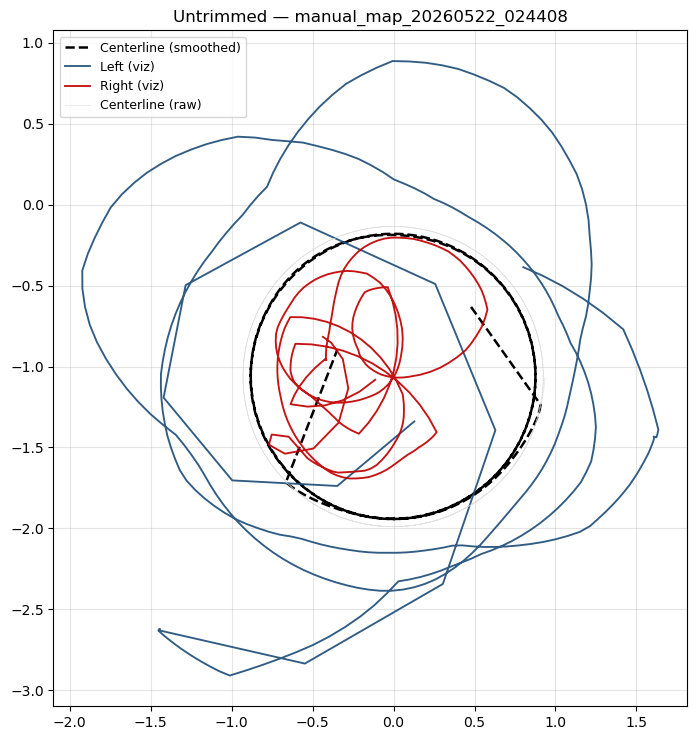

Wrote _plots/manual_map_20260522_024408_untrimmed_centerline_walls.png


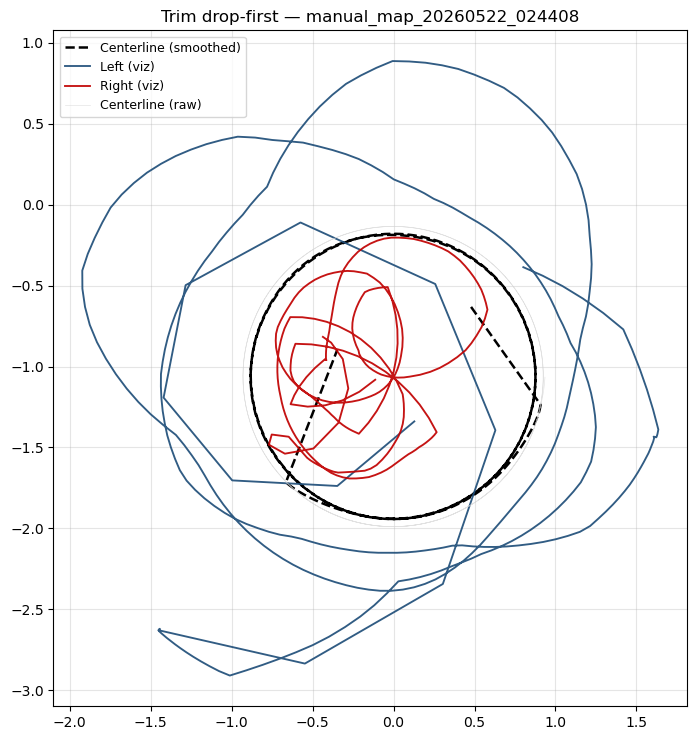

Wrote _plots/manual_map_20260522_024408_trimmed_drop1_centerline_walls.png


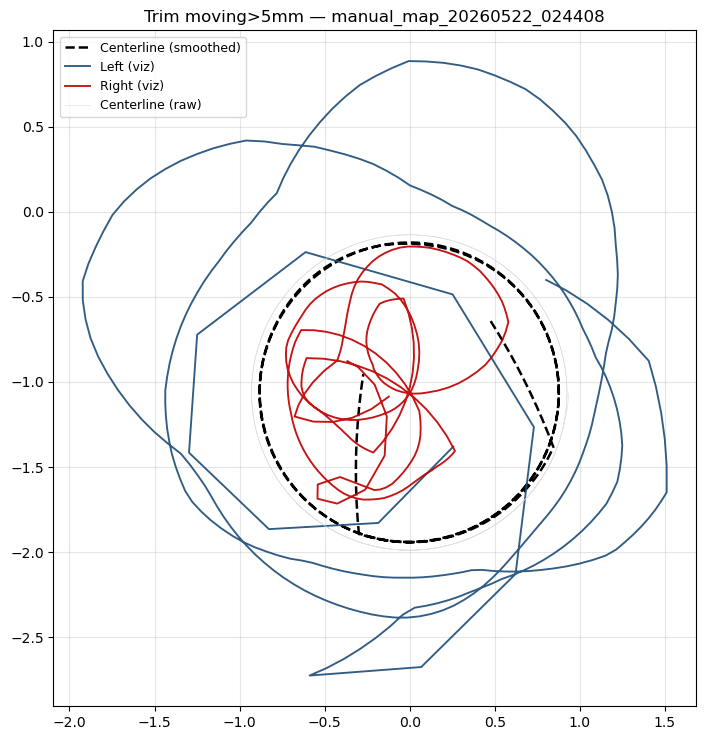

Wrote _plots/manual_map_20260522_024408_trimmed_moving_centerline_walls.png


In [31]:
def _box_smooth(a: np.ndarray, win: int) -> np.ndarray:
    win = max(3, int(win) | 1)
    k = np.ones(win, dtype=float) / float(win)
    return np.convolve(a.astype(float), k, mode="same")


def plot_corridor(d: pd.DataFrame, title: str, file_suffix: str):
    wdf = d[["x", "y", "yaw_rad", "right_wall_m", "left_wall_m"]].rename(
        columns={"x": "x_m", "y": "y_m", "right_wall_m": "w_tr_right_m", "left_wall_m": "w_tr_left_m"}
    )
    x = wdf["x_m"].to_numpy()
    y = wdf["y_m"].to_numpy()
    w_right = wdf["w_tr_right_m"].to_numpy()
    w_left = wdf["w_tr_left_m"].to_numpy()

    WIN_XY, WIN_MED = 21, 25
    xs, ys = _box_smooth(x, WIN_XY), _box_smooth(y, WIN_XY)
    wl = pd.Series(w_left).rolling(WIN_MED, center=True, min_periods=1).median().to_numpy()
    wr = pd.Series(w_right).rolling(WIN_MED, center=True, min_periods=1).median().to_numpy()
    wl = np.clip(_box_smooth(np.nan_to_num(wl, nan=np.nanmedian(wl)), 11), 0.12, 5.0)
    wr = np.clip(_box_smooth(np.nan_to_num(wr, nan=np.nanmedian(wr)), 11), 0.12, 5.0)

    psi_s = _box_smooth(np.unwrap(wdf["yaw_rad"].to_numpy(dtype=float)), WIN_XY)
    nx_l, ny_l = -np.sin(psi_s), np.cos(psi_s)
    lx, ly = xs + nx_l * wl, ys + ny_l * wl
    rx, ry = xs - nx_l * wr, ys - ny_l * wr

    fig, ax = plt.subplots(figsize=(8, 7.5))
    ax.plot(xs, ys, "k--", lw=1.8, label="Centerline (smoothed)")
    ax.plot(lx, ly, color="#1f4e79", lw=1.35, alpha=0.92, label="Left (viz)")
    ax.plot(rx, ry, color="#c00000", lw=1.35, alpha=0.92, label="Right (viz)")
    ax.plot(x, y, color="0.82", lw=0.45, alpha=0.65, label="Centerline (raw)")
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.32)
    ax.legend(loc="upper left", fontsize=9)
    ax.set_title(title)
    plt.tight_layout()
    out = PLOT_DIR / f"{_plot_stem}_{file_suffix}_centerline_walls.png"
    fig.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print("Wrote", out)


def plot_centerline_only(d: pd.DataFrame, title: str, file_suffix: str):
    x, y = d["x"].to_numpy(), d["y"].to_numpy()
    step = np.hypot(np.diff(x), np.diff(y)) if len(x) > 1 else np.array([])
    path_len = float(step.sum())
    gap = float(np.hypot(x[-1] - x[0], y[-1] - y[0])) if len(x) else 0.0
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.plot(x, y, lw=2.2, c="C0", label=f"path {path_len:.1f} m")
    if len(x) > 1:
        ax.plot([x[-1], x[0]], [y[-1], y[0]], "k--", lw=1.2, alpha=0.5, label=f"chord {gap:.1f} m")
    ax.scatter(x[0], y[0], c="g", s=90, zorder=5)
    ax.scatter(x[-1], y[-1], c="r", s=90, zorder=5)
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best", fontsize=8)
    ax.set_title(title)
    plt.tight_layout()
    out = PLOT_DIR / f"{_plot_stem}_{file_suffix}_loop_closure.png"
    fig.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print("Wrote", out)


def plot_corridor_scatter(d: pd.DataFrame, title: str, file_suffix: str):
    """Wall hits as points (no chords) — clearer debug on O-tracks."""
    wdf = d[["x", "y", "yaw_rad", "right_wall_m", "left_wall_m"]].rename(
        columns={"x": "x_m", "y": "y_m", "right_wall_m": "w_tr_right_m", "left_wall_m": "w_tr_left_m"}
    )
    x = wdf["x_m"].to_numpy()
    y = wdf["y_m"].to_numpy()
    wl = wdf["w_tr_left_m"].to_numpy()
    wr = wdf["w_tr_right_m"].to_numpy()
    psi = np.unwrap(wdf["yaw_rad"].to_numpy(dtype=float))
    nx, ny = -np.sin(psi), np.cos(psi)
    lx, ly = x + nx * wl, y + ny * wl
    rx, ry = x - nx * wr, y - ny * wr

    fig, ax = plt.subplots(figsize=(8, 7.5))
    ax.plot(x, y, "k--", lw=1.2, label="Centerline")
    ax.scatter(lx, ly, s=12, c="#1f4e79", alpha=0.75, label="Left hit")
    ax.scatter(rx, ry, s=12, c="#c00000", alpha=0.75, label="Right hit")
    ax.scatter(x[0], y[0], c="g", s=70, zorder=5, label="start")
    ax.scatter(x[-1], y[-1], c="r", s=70, zorder=5, label="end")
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.32)
    ax.legend(loc="upper left", fontsize=9)
    ax.set_title(title)
    plt.tight_layout()
    out = PLOT_DIR / f"{_plot_stem}_{file_suffix}_walls_scatter.png"
    fig.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print("Wrote", out)


plot_corridor(raw_full, f"Untrimmed — {_plot_stem}", "untrimmed")
plot_corridor(trim_drop1, f"Trim drop-first — {_plot_stem}", "trimmed_drop1")
plot_corridor(trim_moving, f"Trim moving>5mm — {_plot_stem}", "trimmed_moving")
plot_corridor(track_one_lap, f"One lap processed — {_plot_stem}", "one_lap_processed")
plot_corridor_scatter(track_one_lap, f"One lap processed (scatter) — {_plot_stem}", "one_lap_processed")
plot_centerline_only(track_one_lap, f"One lap processed path — {_plot_stem}", "one_lap_processed")



In [32]:
df['wall_side_len'] = df['w_tr_right_m'] + df['w_tr_left_m']
df['wall_side_len'].describe()

count    398.000000
mean       1.767969
std        0.500247
min        0.676742
25%        1.433364
50%        1.814879
75%        2.086383
max        3.195865
Name: wall_side_len, dtype: float64

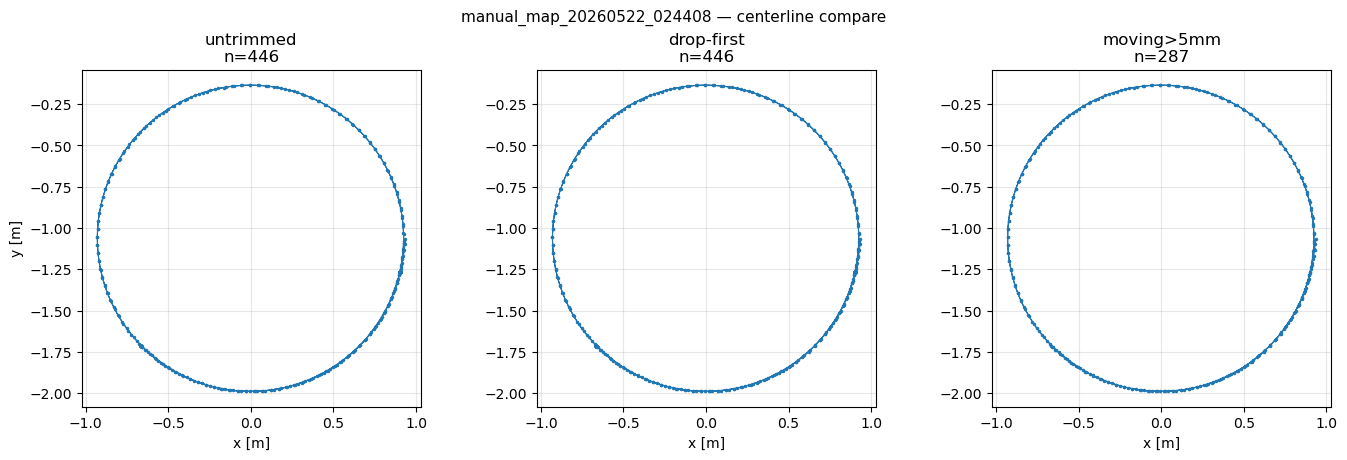

Wrote _plots/manual_map_20260522_024408_untrimmed_vs_trimmed.png


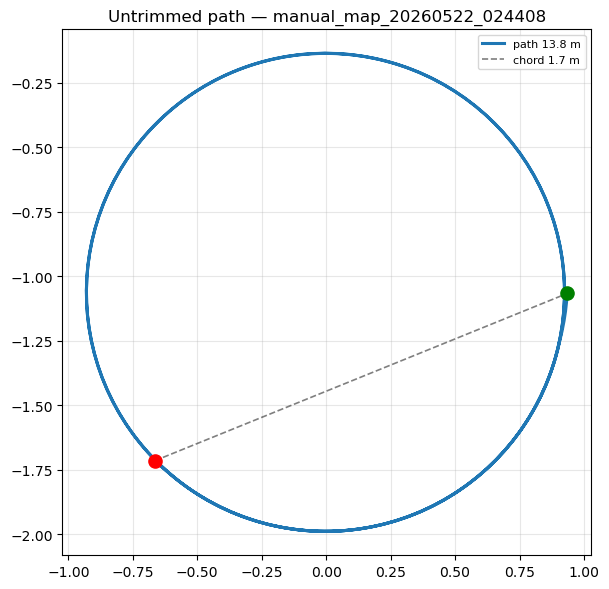

Wrote _plots/manual_map_20260522_024408_untrimmed_loop_closure.png


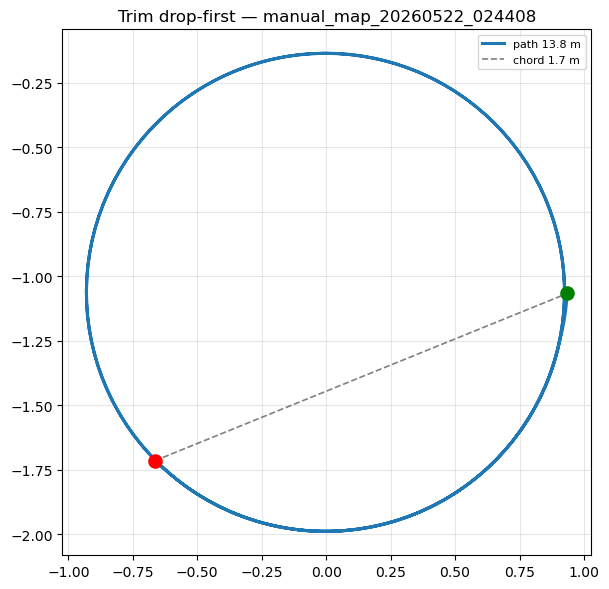

Wrote _plots/manual_map_20260522_024408_trimmed_drop1_loop_closure.png


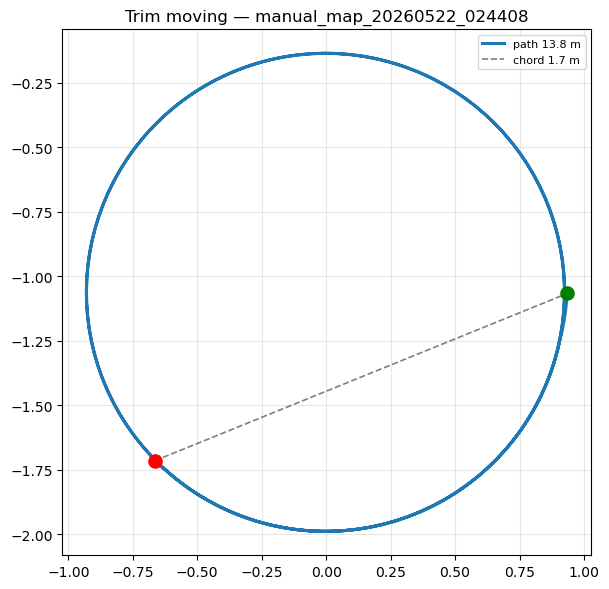

Wrote _plots/manual_map_20260522_024408_trimmed_moving_loop_closure.png


In [33]:
# Side-by-side centerlines (no walls)
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
for ax, d, label in [
    (axes[0], raw_full, f"untrimmed\nn={len(raw_full)}"),
    (axes[1], trim_moving, f"moving>5mm\nn={len(trim_moving)}"),
    (axes[2], track_one_lap, f"one lap proc\nn={len(track_one_lap)}"),
]:
    ax.plot(d["x"], d["y"], ".-", ms=3, lw=0.8)
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.3)
    ax.set_title(label)
axes[0].set_ylabel("y [m]")
for ax in axes:
    ax.set_xlabel("x [m]")
plt.suptitle(f"{_plot_stem} — centerline compare", fontsize=11)
plt.tight_layout()
out = PLOT_DIR / f"{_plot_stem}_untrimmed_vs_trimmed.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print("Wrote", out)

plot_centerline_only(raw_full, f"Untrimmed path — {_plot_stem}", "untrimmed")
plot_centerline_only(trim_drop1, f"Trim drop-first — {_plot_stem}", "trimmed_drop1")
plot_centerline_only(trim_moving, f"Trim moving — {_plot_stem}", "trimmed_moving")

In [34]:
df["t"] = range(len(df))

# Plot x over time/index
plt.figure(figsize=(10,4))

plt.plot(df["t"], df["x_m"])

plt.xlabel("Chronological Index")
plt.ylabel("x_m")
plt.title("x_m Over Track Sequence")

plt.grid(True)
plt.savefig(PLOT_DIR / f"{_plot_stem}_x_over_index.png", dpi=150, bbox_inches="tight")
plt.close()

In [35]:
plt.plot(df["t"], df["y_m"])

plt.xlabel("Chronological Index")
plt.ylabel("y_m")
plt.title("y_m Over Track Sequence")

plt.grid(True)
plt.savefig(PLOT_DIR / f"{_plot_stem}_y_over_index.png", dpi=150, bbox_inches="tight")
plt.close()

### Run analysis (hallway_full)

This section summarizes whether the logged `odom` → `base_link` pose is **physically consistent** (smooth motion) or **dominated by estimator / driver glitches**.

**Healthy hall pass:** integrated path length ≈ few–tens of meters, per-step displacement mostly under a few cm at 20 Hz, yaw changes gradual.

**Broken stack (common in this log):** `vesc_driver_node` **SIGSEGV (-11)** → no reliable wheel odometry → EKF starved / jumping → TF snaps between states. The logger is **correct**; it records the broken tree.

In [36]:
import numpy as np
from collections import Counter

raw = pd.read_csv(_csv)
x, y = raw["x"].to_numpy(), raw["y"].to_numpy()
step = np.hypot(np.diff(x), np.diff(y))
tsec = raw["time_sec"].to_numpy()
dt = np.diff(tsec)
dur = float(tsec[-1] - tsec[0])
path_len = float(step.sum())
med = float(np.median(step)) if len(step) else 0.0
p95 = float(np.percentile(step, 95)) if len(step) else 0.0
p99 = float(np.percentile(step, 99)) if len(step) else 0.0
big = int((step > 0.5).sum())  # >0.5 m between samples => teleport
net = float(np.hypot(x[-1] - x[0], y[-1] - y[0]))

# Laser scan header stamps (staleness check)
if "scan_stamp_sec" in raw.columns:
    ss = pd.to_numeric(raw["scan_stamp_sec"], errors="coerce")
    n_scan_unique = int(ss.round(6).nunique())
    scan_age = tsec - ss.to_numpy()
    scan_age_med = float(np.nanmedian(scan_age))
else:
    n_scan_unique = -1
    scan_age_med = float("nan")

# Pose diversity (rounded mm)
xy_key = [f"{round(a,3)},{round(b,3)}" for a, b in zip(x, y)]
top3 = Counter(xy_key).most_common(3)

print("--- Diagnostics:", _csv.name, "---")
print(f"rows={len(raw)}  duration_s={dur:.2f}  median_dt_ms={1000 * float(np.median(dt)) if len(dt) else 0:.1f}")
print(f"path_length_sum(|Δ|)={path_len:.2f} m  net_displacement_m={net:.2f}")
print(f"step_m: median={med:.4f}  p95={p95:.4f}  p99={p99:.4f}  jumps>0.5m: {big}")
print(f"x range [{x.min():.3f}, {x.max():.3f}]  y range [{y.min():.3f}, {y.max():.3f}]")
dyaw = (raw["yaw_rad"].iloc[-1] - raw["yaw_rad"].iloc[0]) * 57.2958
print(f"Δyaw start→end (deg): {dyaw:.1f}")
print(f"unique scan_stamp_sec (rounded): {n_scan_unique}  (want many for a long run; ~4 => stale /scan)")
print(f"median(time_sec - scan_stamp_sec) s: {scan_age_med:.3f}  (large => scan older than pose)")
print("top (x,y) rounded mm counts:", top3)


--- Diagnostics: manual_map_20260522_024408.csv ---
rows=446  duration_s=44.50  median_dt_ms=100.0
path_length_sum(|Δ|)=13.84 m  net_displacement_m=1.73
step_m: median=0.0483  p95=0.0517  p99=0.0537  jumps>0.5m: 0
x range [-0.930, 0.935]  y range [-1.989, -0.135]
Δyaw start→end (deg): 232.7
unique scan_stamp_sec (rounded): 353  (want many for a long run; ~4 => stale /scan)
median(time_sec - scan_stamp_sec) s: 0.198  (large => scan older than pose)
top (x,y) rounded mm counts: [('0.902,-1.269', 120), ('-0.665,-1.715', 40), ('0.07,-1.986', 2)]


In [37]:
# Extra: step size distribution and scan freshness vs index
raw2 = pd.read_csv(_csv)
st = np.hypot(np.diff(raw2["x"]), np.diff(raw2["y"]))
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].hist(st, bins=60, color="#2a6f97", edgecolor="white", linewidth=0.3)
ax[0].set_xlabel("Step m (hypot Δx, Δy)")
ax[0].set_ylabel("count")
ax[0].set_title("Per-sample displacement")
ax[0].axvline(0.5, color="r", linestyle="--", label="0.5 m (teleport threshold)")
ax[0].legend()

if "scan_stamp_sec" in raw2.columns:
    ss = pd.to_numeric(raw2["scan_stamp_sec"], errors="coerce").to_numpy()
    age = raw2["time_sec"].to_numpy() - ss
    ax[1].plot(np.arange(len(age)), age, lw=0.8)
    ax[1].set_xlabel("Index")
    ax[1].set_ylabel("time_sec - scan_stamp_sec (s)")
    ax[1].set_title("Scan freshness (pose time - scan header)")
else:
    ax[1].text(0.5, 0.5, "no scan_stamp_sec", ha="center")
fig.tight_layout()
plt.savefig(PLOT_DIR / f"{_plot_stem}_steps_scan_age.png", dpi=150, bbox_inches="tight")
plt.close()
print("Wrote", PLOT_DIR / f"{_plot_stem}_steps_scan_age.png")

Wrote _plots/manual_map_20260522_024408_steps_scan_age.png


### Loop / “cyclical” check (`map` hall log)

**Cyclical** here means the path **returns near the start** (small **start–end gap** vs **path length**). Your `map_hall` run is mostly an **open traverse** (start and end in different corners), so the chord is **long** — that is expected, not a bug.

The noisy blue “corridor” on the auto slide was **raw scan-window ranges** projected perpendicular to the path; it is **not** the SLAM occupancy grid. Use **`plot_presentation_map.py --corridor smooth`** (default now) or **`--corridor off`** for a clean centerline-only slide.

In [38]:
# Same trim as pipeline: drop first row (SLAM startup snap), then closure metrics.
raw = pd.read_csv(_csv)
dfm = raw.iloc[1:].copy()
x, y = dfm["x"].to_numpy(), dfm["y"].to_numpy()
step = np.hypot(np.diff(x), np.diff(y))
path_len = float(step.sum())
gap = float(np.hypot(x[-1] - x[0], y[-1] - y[0]))
print("file:", _csv.name)
print("trimmed rows:", len(dfm))
print("path_length_m:", round(path_len, 2))
print("start-end gap_m:", round(gap, 2), "  gap/path:", round(gap / max(path_len, 1e-9), 3))
approx_closed = (gap < 0.05 * path_len) and (gap < 3.0)
print("approximately closed loop?", approx_closed)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(x, y, lw=2.4, c="C0", label="centerline (trimmed)")
ax.plot([x[-1], x[0]], [y[-1], y[0]], "k--", lw=1.5, alpha=0.6, label=f"closure chord {gap:.1f} m")
ax.scatter(x[0], y[0], c="g", s=120, zorder=5)
ax.scatter(x[-1], y[-1], c="r", s=120, zorder=5)
ax.set_aspect("equal")
ax.grid(True, alpha=0.3)
ax.legend(loc="best")
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_title("Cyclical? (gap vs path length)")
fig.savefig(PLOT_DIR / f"{_plot_stem}_loop_closure_check.png", dpi=150, bbox_inches="tight")
plt.close()
print("Wrote", PLOT_DIR / f"{_plot_stem}_loop_closure_check.png")

file: manual_map_20260522_024408.csv
trimmed rows: 445
path_length_m: 13.81
start-end gap_m: 1.71   gap/path: 0.124
approximately closed loop? False
Wrote _plots/manual_map_20260522_024408_loop_closure_check.png
